
Information:

age, gender, bp, cholesterol, na_to_k sodium to potassium inb blood, classify what drug

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

### Reading Data

In [54]:
df = pd.read_csv("./prelim_dataset.csv")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [55]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [57]:
# Separate the numerical and categorical columns into an array for reference

numerical_cols_list = ["Age", "Na_to_K"]
categorical_cols_list = ["Sex", "BP", "Cholesterol", "Drug"]

Attempt to check for error values

In [58]:
for col in numerical_cols_list:
    print(df[col].name)
    print(df[col].unique())

Age
[23 47 28 61 22 49 41 60 43 34 74 50 16 69 32 57 63 48 33 31 39 45 18 65
 53 46 15 73 58 66 37 68 67 62 24 26 40 38 29 17 54 70 36 19 64 59 51 42
 56 20 72 35 52 55 30 21 25]
Na_to_K
[25.355 13.093 10.114  7.798 18.043  8.607 16.275 11.037 15.171 19.368
 11.767 19.199 15.376 20.942 12.703 15.516 11.455 13.972  7.298 25.974
 19.128 25.917 30.568 15.036 33.486 18.809 30.366  9.381 22.697 17.951
  8.75   9.567 11.014 31.876 14.133  7.285  9.445 13.938  9.709  9.084
 19.221 14.239 15.79  12.26  12.295  8.107 13.091 10.291 31.686 19.796
 19.416 10.898 27.183 18.457 10.189 14.16  11.34  27.826 10.091 18.703
 29.875  9.475 20.693  8.37  13.303 27.05  12.856 10.832 24.658 24.276
 13.967 19.675 10.605 22.905 17.069 20.909 11.198 19.161 13.313 10.84
 13.934  7.761  9.712 11.326 10.067 13.935 13.597 15.478 23.091 17.211
 16.594 15.156 29.45  29.271 15.015 11.424 38.247 25.395 35.639 16.725
 11.871 12.854 13.127  8.966 28.294  8.968 11.953 20.013  9.677 16.85
  7.49   6.683  9.17  13.769  9.28

In [59]:
for col in categorical_cols_list:
    print(df[col].name)
    print(df[col].unique())

Sex
['F' 'M']
BP
['HIGH' 'LOW' 'NORMAL']
Cholesterol
['HIGH' 'NORMAL']
Drug
['DrugY' 'drugC' 'drugX' 'drugA' 'drugB']


In [60]:
# Drug has inconsistent naming, transform for one hot encoding later
df["Drug"] = df["Drug"].str.lower()

In [61]:
# Check if Drug now has consistent naming
df.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugy
1,47,M,LOW,HIGH,13.093,drugc
2,47,M,LOW,HIGH,10.114,drugc
3,28,F,NORMAL,HIGH,7.798,drugx
4,61,F,LOW,HIGH,18.043,drugy
5,22,F,NORMAL,HIGH,8.607,drugx
6,49,F,NORMAL,HIGH,16.275,drugy
7,41,M,LOW,HIGH,11.037,drugc
8,60,M,NORMAL,HIGH,15.171,drugy
9,43,M,LOW,NORMAL,19.368,drugy


Check for duplicates and null values

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

### Encoding

In [64]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [65]:
# Use Label Encoder for Sex
# since it is binary data (M and F)
le = LabelEncoder()

# Use Ordinal Encoder for BP and Cholesterol.
# Considering value ranges: Low, Normal, High
ore = OrdinalEncoder(categories=[[
    "LOW",
    "NORMAL",
    "HIGH"
]])

# Use the One Hot Encoding for the Drug Column.
# since the column contains a set of nominal data without order
ohe = OneHotEncoder(sparse_output=False)

In [66]:
df["Sex"] = le.fit_transform(df["Sex"])
# 0 is F
# 1 is M

In [67]:
df["BP"] = ore.fit_transform(df[["BP"]])
df["Cholesterol"] = ore.fit_transform(df[["Cholesterol"]])

In [68]:
ohe_df = pd.DataFrame(ohe.fit_transform(df[["Drug"]]), columns=ohe.get_feature_names_out(["Drug"]))

# Concatenated the new One Hot Encoded Dataframe to original data frame
# without the Drug column
encoded_df = pd.concat([df.drop(columns=["Drug"]), ohe_df], axis=1)

encoded_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug_druga,Drug_drugb,Drug_drugc,Drug_drugx,Drug_drugy
0,23,0,2.0,2.0,25.355,0.0,0.0,0.0,0.0,1.0
1,47,1,0.0,2.0,13.093,0.0,0.0,1.0,0.0,0.0
2,47,1,0.0,2.0,10.114,0.0,0.0,1.0,0.0,0.0
3,28,0,1.0,2.0,7.798,0.0,0.0,0.0,1.0,0.0
4,61,0,0.0,2.0,18.043,0.0,0.0,0.0,0.0,1.0


In [69]:
# Check for types on the new DF
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    float64
 3   Cholesterol  200 non-null    float64
 4   Na_to_K      200 non-null    float64
 5   Drug_druga   200 non-null    float64
 6   Drug_drugb   200 non-null    float64
 7   Drug_drugc   200 non-null    float64
 8   Drug_drugx   200 non-null    float64
 9   Drug_drugy   200 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 15.8 KB


## Data Analysis

<Axes: xlabel='Age', ylabel='Count'>

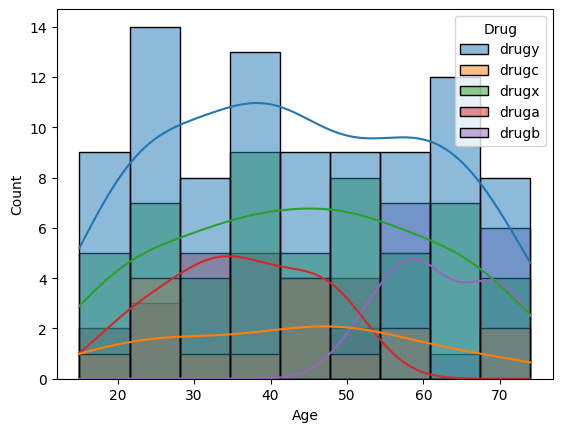

In [70]:
sns.histplot(data=df, x="Age", kde=True, hue="Drug")

Based on the graph, Age is distributed well without noticeable skewness

<Axes: xlabel='Na_to_K', ylabel='Count'>

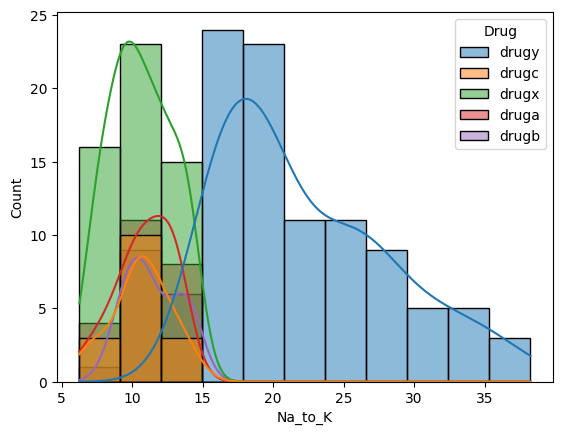

In [71]:
sns.histplot(data=df, x="Na_to_K", kde=True, hue="Drug")

Na_to_K has a slight right skewness

Try to programatically get the value of the skewness, and get an interpretation

In [72]:
"""
Helper for identlifying skewness
"""
def get_skew(col):
    print("Skewness of", col, ":", df[col].skew())

    # Skewness more than 1 or less than 1: Highly Skewed
    if df[col].skew() > 1 or df[col].skew() < -1:
        print(f"{col} is highly skewed.")
    
    # Skewness between 1 to 0.5 or between -1 to -0.5: Moderately Skewed
    elif df[col].skew() > 0.5 or df[col].skew() < -0.5:
        print(f"{col} is moderately skewed.")

    # Symmetric if between 0.5 to -0.5
    else:
        print(f"{col} is approximately symmetric.")
    print("\n")
    

In [73]:
get_skew("Age")
get_skew("Na_to_K")

Skewness of Age : 0.03030835703000607
Age is approximately symmetric.


Skewness of Na_to_K : 1.039341186028881
Na_to_K is highly skewed.




Heatmap

<Axes: >

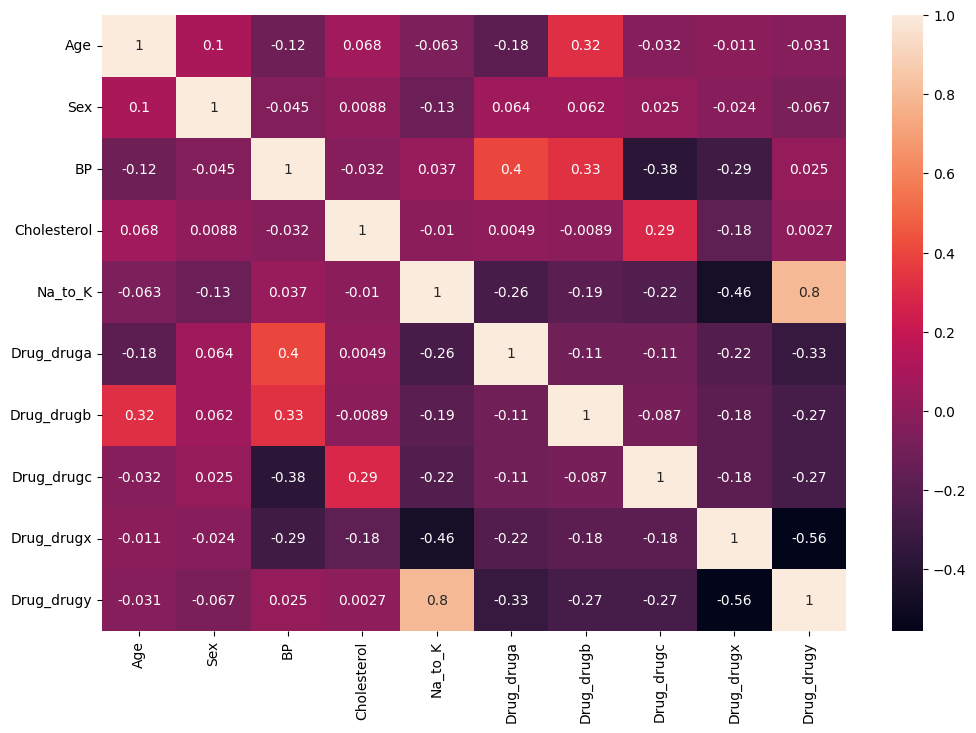

In [74]:
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(encoded_df.corr(), annot=True)

From the findings, take note of the following:

Correlation to the following Drugs:
(between 1 to 0.2, -0.2 to -1)


DrugA:
- BP (0.4)
- NA_to_K (-0.26)

DrugB:
- BP (0.33)
- Age (0.32)

DrugC:
- BP (-0.38)
- Cholesterol (0.29)

DrugX:
- Na_to_K (-0.46)
- BP (-0.29)

DrugY:
- Na_to_K (0.8)

### Dealing with Outliers, Extreme Cases and Erroneous Data Inputs

In [75]:
"""
Remove outliers based on IQR
"""
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data

In [76]:
"""
Prints both the upper and lower bounds of the quartile
"""
def show_bounds_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print("lower bound", lower_bound)
    print("upper bound", upper_bound) 

In [77]:
"""
Get the extremes based on the threshold depending on the median
(how far it is on the median)
"""
def check_extremes_from_edges(series, threshold=0.30):
 
    median = series.median()
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val

    lower_bound = median - threshold * range_val
    upper_bound = median + threshold * range_val

    return {
        "min_value": min_val,
        "min_class": "Lower Extreme" if min_val < lower_bound else "Normal",
        "max_value": max_val,
        "max_class": "Upper Extreme" if max_val > upper_bound else "Normal",
        "median": median,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

#### Boxplot for Drugs based on the listed columns with correlation.

Drug A

<Axes: xlabel='Drug_druga', ylabel='Na_to_K'>

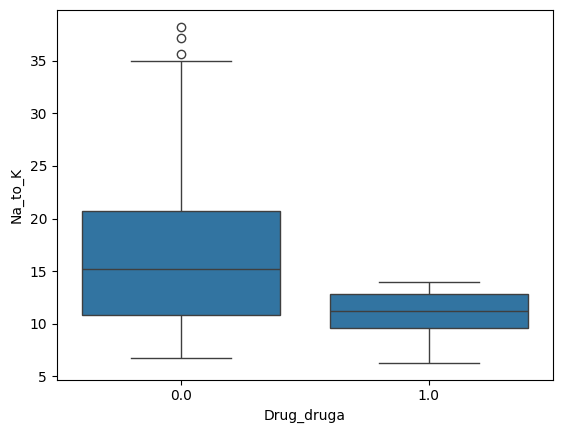

In [78]:
sns.boxplot(data=encoded_df, y='Na_to_K', x='Drug_druga')

Get the average based of Na_to_K where Drug A is positive.

<Axes: xlabel='BP', ylabel='Drug_druga'>

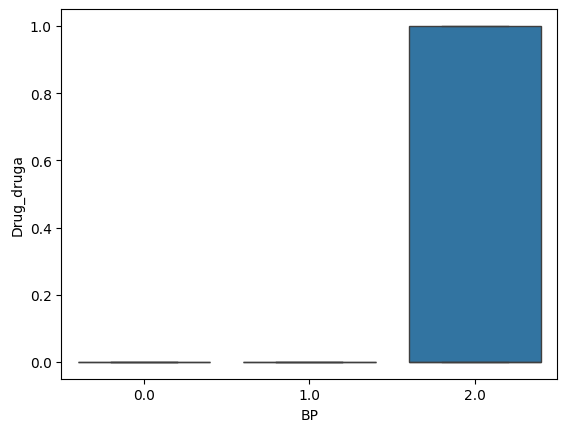

In [79]:
sns.boxplot(data=encoded_df, x='BP', y='Drug_druga')

Assuming that the BP is 2.0 (High) then person must be intaking Drug A

Drug B

<Axes: xlabel='BP', ylabel='Drug_drugb'>

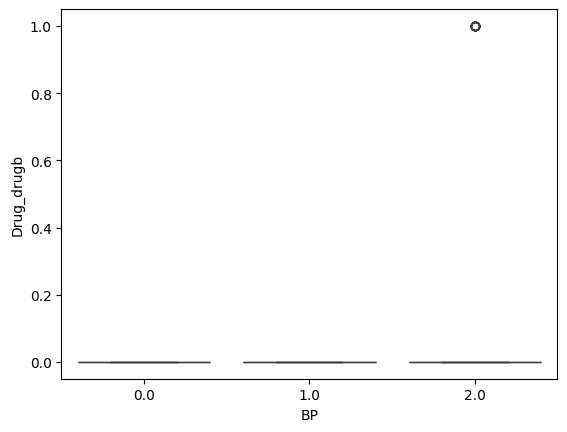

In [80]:
sns.boxplot(data=encoded_df, x='BP', y='Drug_drugb')

Skip

<Axes: xlabel='Drug_drugb', ylabel='Age'>

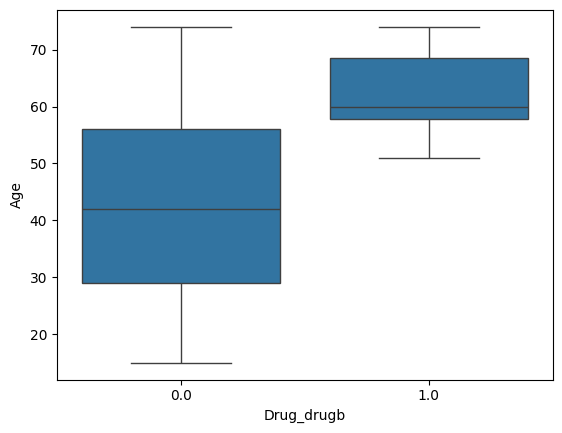

In [81]:
sns.boxplot(data=encoded_df, y='Age', x='Drug_drugb')


Get the average based of Age where Drug B is positive.

Drug X

<Axes: xlabel='Drug_drugx', ylabel='Na_to_K'>

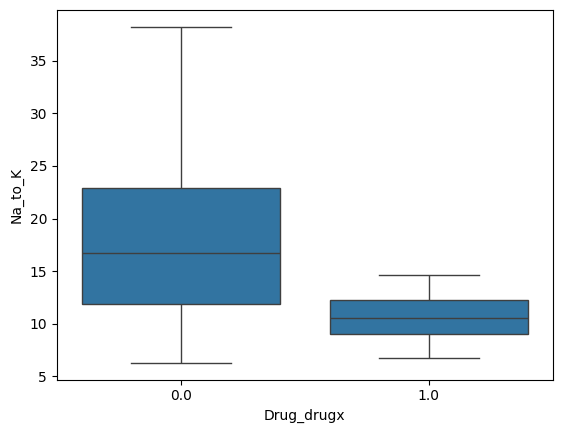

In [82]:
sns.boxplot(data=encoded_df, y='Na_to_K', x='Drug_drugx')

Get the average based of Age where Drug B is positive.

<Axes: xlabel='BP', ylabel='Drug_drugx'>

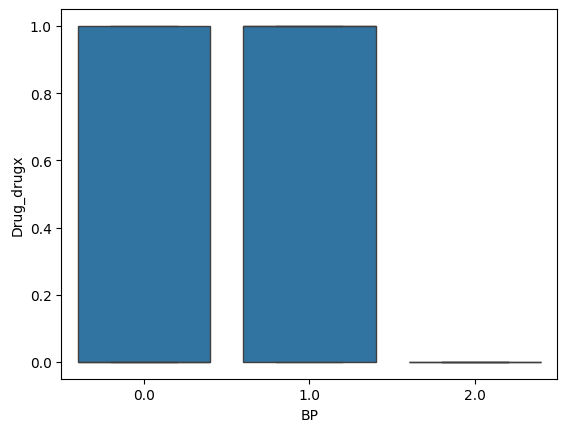

In [83]:
sns.boxplot(data=encoded_df, x='BP', y='Drug_drugx')

Assuming that the BP is 0.0 (Low) or 1.0 (Medium) then it must be intaking Drug x.

Drug Y

<Axes: xlabel='Drug_drugy', ylabel='Na_to_K'>

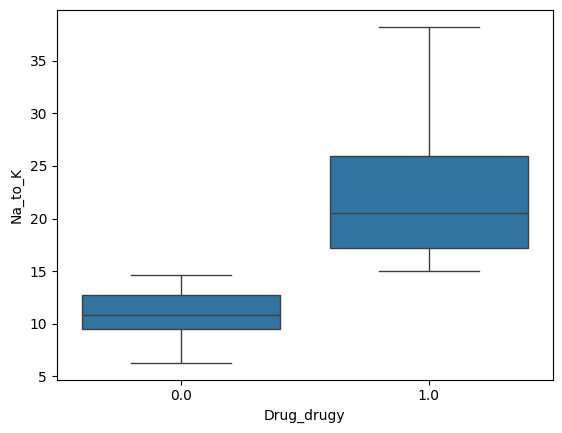

In [84]:
sns.boxplot(data=encoded_df, y='Na_to_K', x='Drug_drugy')

Get the average based of Na_to_K where Drug Y is positive.

Assess numerical columns and their extremes and remove outliers

In [85]:
for col in numerical_cols_list:
    print("col: ", col)

    # Print the bounds
    show_bounds_iqr(encoded_df, col)

    # Get the extremes of the column
    print(check_extremes_from_edges(encoded_df[col]))

    # Then remove the outliers
    encoded_df = remove_outliers_iqr(encoded_df, col)

col:  Age
lower bound -9.5
upper bound 98.5
{'min_value': np.int64(15), 'min_class': 'Lower Extreme', 'max_value': np.int64(74), 'max_class': 'Upper Extreme', 'median': np.float64(45.0), 'lower_bound': np.float64(27.3), 'upper_bound': np.float64(62.7)}
col:  Na_to_K
lower bound -2.9562500000000007
upper bound 32.78175
{'min_value': np.float64(6.269), 'min_class': 'Normal', 'max_value': np.float64(38.247), 'max_class': 'Upper Extreme', 'median': np.float64(13.9365), 'lower_bound': np.float64(4.3431), 'upper_bound': np.float64(23.5299)}


Considering that Na_to_K and Drug A correlation had an outlier earlier, check if removed now.

<Axes: xlabel='Drug_druga', ylabel='Na_to_K'>

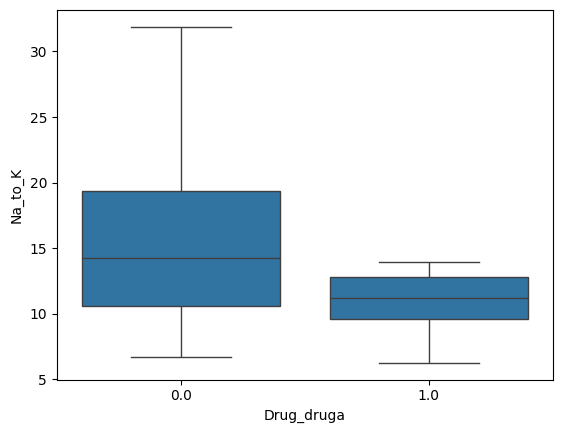

In [86]:
sns.boxplot(data=encoded_df, y='Na_to_K', x='Drug_druga')

## Feature Encoding

In [87]:
encoded_df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug_druga,Drug_drugb,Drug_drugc,Drug_drugx,Drug_drugy
0,23,0,2.0,2.0,25.355,0.0,0.0,0.0,0.0,1.0
1,47,1,0.0,2.0,13.093,0.0,0.0,1.0,0.0,0.0
2,47,1,0.0,2.0,10.114,0.0,0.0,1.0,0.0,0.0
3,28,0,1.0,2.0,7.798,0.0,0.0,0.0,1.0,0.0
4,61,0,0.0,2.0,18.043,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
195,56,0,0.0,2.0,11.567,0.0,0.0,1.0,0.0,0.0
196,16,1,0.0,2.0,12.006,0.0,0.0,1.0,0.0,0.0
197,52,1,1.0,2.0,9.894,0.0,0.0,0.0,1.0,0.0
198,23,1,1.0,1.0,14.020,0.0,0.0,0.0,1.0,0.0


In [88]:

"""
Based off the findings on the Heatmap and Boxplots,
assume a range based on the average distribution shown in the
Boxplots
"""

encoded_df["DrugA Chance by Na_to_K"] = encoded_df["Na_to_K"].apply(lambda x: 1 if 11 < x < 13 else 0)
encoded_df["DrugA Chance by BP"] = encoded_df["BP"].apply(lambda bp: 1 if bp == 2 else 0)

encoded_df["DrugB Chance"] = encoded_df["Age"].apply(lambda age: 1 if 58 < age < 78 else 0)
# Dont include BP because of outlier

encoded_df["DrugX Chance by Na_to_K"] = encoded_df["Na_to_K"].apply(lambda x: 1 if 11 < x < 13 else 0)
encoded_df["DrugX Chance by BP"] = encoded_df["BP"].apply(lambda bp: 1 if bp == 0 or bp == 1 else 0)

encoded_df["DrugY Chance "] = encoded_df["Na_to_K"].apply(lambda x: 1 if 15 < x < 30 else 0)


In [89]:
# Check if columns are properly working
encoded_df.head(20)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug_druga,Drug_drugb,Drug_drugc,Drug_drugx,Drug_drugy,DrugA Chance by Na_to_K,DrugA Chance by BP,DrugB Chance,DrugX Chance by Na_to_K,DrugX Chance by BP,DrugY Chance
0,23,0,2.0,2.0,25.355,0.0,0.0,0.0,0.0,1.0,0,1,0,0,0,1
1,47,1,0.0,2.0,13.093,0.0,0.0,1.0,0.0,0.0,0,0,0,0,1,0
2,47,1,0.0,2.0,10.114,0.0,0.0,1.0,0.0,0.0,0,0,0,0,1,0
3,28,0,1.0,2.0,7.798,0.0,0.0,0.0,1.0,0.0,0,0,0,0,1,0
4,61,0,0.0,2.0,18.043,0.0,0.0,0.0,0.0,1.0,0,0,1,0,1,1
5,22,0,1.0,2.0,8.607,0.0,0.0,0.0,1.0,0.0,0,0,0,0,1,0
6,49,0,1.0,2.0,16.275,0.0,0.0,0.0,0.0,1.0,0,0,0,0,1,1
7,41,1,0.0,2.0,11.037,0.0,0.0,1.0,0.0,0.0,1,0,0,1,1,0
8,60,1,1.0,2.0,15.171,0.0,0.0,0.0,0.0,1.0,0,0,1,0,1,1
9,43,1,0.0,1.0,19.368,0.0,0.0,0.0,0.0,1.0,0,0,0,0,1,1


## Preprocessing

In [90]:
# copy the df
df_final = encoded_df.copy()

### Split Data

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
df_final.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug_druga',
       'Drug_drugb', 'Drug_drugc', 'Drug_drugx', 'Drug_drugy',
       'DrugA Chance by Na_to_K', 'DrugA Chance by BP', 'DrugB Chance',
       'DrugX Chance by Na_to_K', 'DrugX Chance by BP', 'DrugY Chance '],
      dtype='object')

In [93]:
# Considering we are finding what type of drug based on the features,
# Drop Drug columns on X and have them in y

# Features
X = df_final.drop(columns=['Drug_druga',
       'Drug_drugb', 'Drug_drugc', 'Drug_drugx', 'Drug_drugy'])

# Target
y = df_final[['Drug_druga',
       'Drug_drugb', 'Drug_drugc', 'Drug_drugx', 'Drug_drugy']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [94]:
# Check X columns
X

,Age,Sex,BP,Cholesterol,Na_to_K,DrugA Chance by Na_to_K,DrugA Chance by BP,DrugB Chance,DrugX Chance by Na_to_K,DrugX Chance by BP,DrugY Chance
0,23,0,2.0,2.0,25.355,0,1,0,0,0,1
1,47,1,0.0,2.0,13.093,0,0,0,0,1,0
2,47,1,0.0,2.0,10.114,0,0,0,0,1,0
3,28,0,1.0,2.0,7.798,0,0,0,0,1,0
4,61,0,0.0,2.0,18.043,0,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
195,56,0,0.0,2.0,11.567,1,0,0,1,1,0
196,16,1,0.0,2.0,12.006,1,0,0,1,1,0
197,52,1,1.0,2.0,9.894,0,0,0,0,1,0
198,23,1,1.0,1.0,14.020,0,0,0,0,1,0


In [95]:
# Check y columns
y

,Drug_druga,Drug_drugb,Drug_drugc,Drug_drugx,Drug_drugy
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
195,0.0,0.0,1.0,0.0,0.0
196,0.0,0.0,1.0,0.0,0.0
197,0.0,0.0,0.0,1.0,0.0
198,0.0,0.0,0.0,1.0,0.0


### Scaling

In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [97]:
print("Old Scale: ")
print(np.min(X_train)," <-> " ,np.max(X_train))

Old Scale: 
0.0  <->  74.0


In [98]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [99]:
print("New Scale: ")
print(np.min(X_train_scaled), " <-> ", np.max(X_train_scaled))

New Scale: 
-1.7286456487016004  <->  2.6187310617948287


## Classification

After splitting, and scaling the data, proceed with classification

In [100]:
from sklearn.metrics import classification_report, accuracy_score

K Nearest

In [101]:
from sklearn.neighbors import KNeighborsClassifier
# use the sqrt to get the number of neighbors
k = int(np.sqrt(len(y_test)))
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))
print("Accuracy:", knn_accuracy)

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.67      0.67      0.67         3
           2       1.00      0.33      0.50         3
           3       0.92      1.00      0.96        11
           4       1.00      0.88      0.94        17

   micro avg       0.94      0.87      0.91        39
   macro avg       0.92      0.78      0.81        39
weighted avg       0.95      0.87      0.90        39
 samples avg       0.87      0.87      0.87        39

Accuracy: 0.8717948717948718


/Users/cxnner05/Documents/uni_notes/year 3/lab-ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Decision Tree

In [102]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
dtc_pred = dtc.predict(X_test)
dtc_accuracy = accuracy_score(y_test, dtc_pred)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dtc_pred))
print("Accuracy:", dtc_accuracy)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        17

   micro avg       1.00      1.00      1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39
 samples avg       1.00      1.00      1.00        39

Accuracy: 1.0


Random Forest

In [103]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_test, rfc_pred)
print("Random Forest Classification Report:")
print(classification_report(y_test, rfc_pred))
print("Accuracy:", rfc_accuracy)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        17

   micro avg       1.00      1.00      1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39
 samples avg       1.00      1.00      1.00        39

Accuracy: 1.0


([0, 1, 2],
 [Text(0, 0, 'K-Nearest Neighbors'),
  Text(1, 0, 'Decision Tree'),
  Text(2, 0, 'Random Forest')])

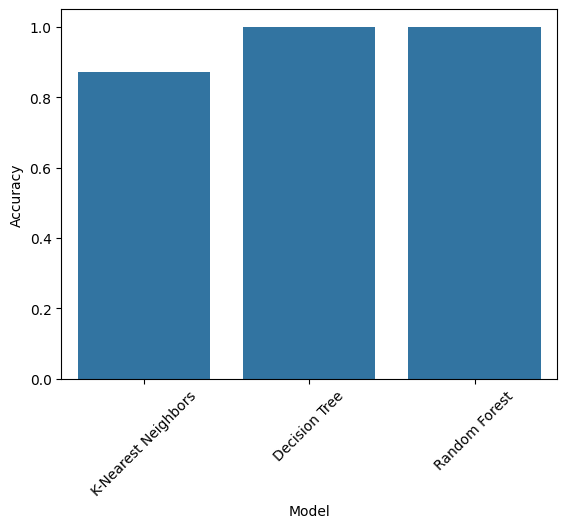

In [104]:
comparison = pd.DataFrame({
    'Model': ['K-Nearest Neighbors', 'Decision Tree', 'Random Forest'],
    'Accuracy': [knn_accuracy, dtc_accuracy, rfc_accuracy]
})

sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.xticks(rotation=45)

Based on the results, both Decision Tree and Random Forest are the most accurate with a score of 1.0.